# Review of statistics concepts crucial for Data Science


## Key Terms for Estimates of Location
1. Mean - sum of all the avlues divided by the number of values
2. Weighted mean - sum of all the avlues times a weight divided by the sum of the weights
3. Median - the value such that one-half of the data lies above and below. Median is same with 50th percentile
4. Percentile - the value such taht P percent of the data lies below
5. Weighted median - the value such that one-half of the sum of the wieghts lies above and below the sorted data
6. Trimmed mean - the average of all values after dropping a fixed number of extreme values
7. Robust - not sensitive to extreme values
8. Outlier - a data value that is very different from most of the data

Trimmed mean  - variant of mean, where you drop fixed number of sorted values at each end and then calculate the average of the remaining values. Purpose of trimmed mean is to reduce impact of outliers on the value of mean.

In [32]:
#%pip install scipy
%pip install pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:

import pandas as pd
import scipy.stats as stats
import numpy as np 

In [34]:
pd.options.display.float_format = '{:.2f}'.format

In [35]:
state_df = pd.read_csv("state.csv")

In [36]:
state_df.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.70,AL
1,Alaska,710231,5.60,AK
2,Arizona,6392017,4.70,AZ
3,Arkansas,2915918,5.60,AR
4,California,37253956,4.40,CA


In [37]:
state_df.dtypes

State               str
Population        int64
Murder.Rate     float64
Abbreviation        str
dtype: object

In [38]:
state_df["Population"].mean()

np.float64(6162876.3)

In [39]:
stats.trim_mean(state_df["Population"],0.1)

np.float64(4783697.125)

In [40]:
state_df["Population"].median()

np.float64(4436369.5)

Above comparison presents exactly things mentioned earlier - mean is sensitive to outliers and such values can have great impact on the value of mean. Trimmed mean on the other hand have value close to the value of median.

In [41]:
np.average(state_df["Murder.Rate"], weights=state_df["Population"])

np.float64(4.445833981123393)

In [42]:
state_df["Murder.Rate"].mean()

np.float64(4.066)

In [43]:
%pip install wquantiles



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [44]:
import wquantiles

In [45]:
wquantiles.median(state_df["Murder.Rate"], weights=state_df["Population"])

np.float64(4.4)

Above comparison again confirms the advantege of weighted mean above regular mean. Considering murder rate average and not including the population of state we miss the bigger picture, which is that those values depends on each other

## Immunity to the outlieres
Statistics such as mean, variance, standard deviation and similar, are not immune to the outliers. This means that their value could be highly affected by records with values significantly larger or lower, than the rest of the population. In that case we would get false view onto the data, for example if we would like to now the mean income of some neighbourhood, and it would happen that in there would live some bilionaire, the income of him would greatly enlarged the mean value and as result we would have false informations. 

### Estimators immune to the outliers and estimators of positon

There are several ways we can avoid getting false value of estimator. In order to acheive it we can sort our data, and cut down equal number records from the beginning and end. 

However, there is different aproach that don't need such actions. 

</br> **Estimators of position** are estimators that gives us information how the data spreads. Most popular of them is median, which divides dataset into to equal subdatasets. Median tells us that 50% of data have value lesser  or equal than given value, and that the other 50% have value that exceed it. Median is known also as 50th percentile or 2nd quartile. Percentiles are relted to the percents. 10th percentile says that 10% of the records have values below it or on that level, and 90% have bigger value
<br> Other order statistics are for example: quartiles (which divide the dataset into 4 equal parts) and quantiles (which divide the dataset into 10 equal parts).  

### Calculating percentiles 
To calculate the position of the percentile, we use the following equation:  <br> <br>
i = (k * (n+1))/100, where <br>
i is the index of the percentile we calculate<br>
k is the value of percentile<br>
n is the total number of records that there are in the dataset
<br>
<br>
Depending on the count of the records (if its even or odd), we can receive different value for the possition/ index of our percentile. When we receive integer, finding percentile is straightforward, however if its decimal, we calculate the value of percentile from the following equation:<br><br>
P = x(i) + d * (x(i+1) - x(i)), where <br>
x(i) is the value on integer part of i position of dataset <br>
d is the decimal part of index i <br>
x(i+1) is the value on integer part of i position of dataset + 1 <br>


In [46]:
state_df["Population"].std()

np.float64(6848235.347401142)

In [47]:
state_df["Population"].quantile(0.75) - state_df["Population"].quantile(0.25)

np.float64(4847308.0)

Difference above is known as interquartile range (IQR). It is a diffrence of 75th percentile (which marks the threshhold that 75% of records have value less or equal to) and the 25th percentile (25 % of values have value less or equal than that). That difference tells us about the spread of data.

In [49]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 8.1 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [51]:
from statsmodels import robust

In [52]:
robust.scale.mad(state_df["Population"])

np.float64(3849876.1459979336)

Above estimator is MAD - Mean absolute deviation, which is average of difference of records and mean of dataset. 
MAD is more robust than variance and standard deviation, which are sensitive to the outlieres. We can see that above, standard deviation is almost 2 times higher than MAD

## Exploring the Data Distribution


In [53]:
state_df['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05   1.60
0.25   2.42
0.50   4.00
0.75   5.55
0.95   6.51
Name: Murder.Rate, dtype: float64

Above there are percentiles calculated for murder rate column (number of murders per 100k people). 5th percentile means that 5% of the records have murder rate less or equal to the 1.6, while 95th percentile says that 95% of the records have murder rate at 6.51 per 100k or less. Only 5% of the records have murder rate above that treshhold

In [54]:
state_df.describe()

,Population,Murder.Rate
count,50.00,50.00
mean,6162876.30,4.07
std,6848235.35,1.92
min,563626.00,0.90
25%,1833004.25,2.42
50%,4436369.50,4.00
75%,6680312.25,5.55
max,37253956.00,10.30


In [58]:
%pip install matplotlib
import matplotlib.pyplot as plt

  Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.6 MB/s  0:00:00 eta 0:00:01
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotl

Text(0, 0.5, 'Population (millions)')

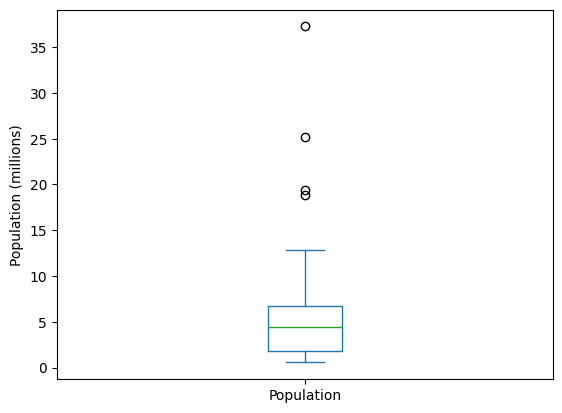

In [65]:
# ax = plt.boxplot(state_df["Population"]/1_000_000)
# ax.set_ylabel()
ax = (state_df['Population']/1_000_000).plot.box()
ax.set_ylabel('Population (millions)')

### Frequancy tables and Histograms
Frequancy tables are used to display distribution of data among equaly spaced bins/intervals. 

In [ ]:
binned_population = pd.cut(state_df["Population"], 10)




0       (4232659.0, 7901692.0]
1       (526935.67, 4232659.0]
2       (4232659.0, 7901692.0]
3       (526935.67, 4232659.0]
4     (33584923.0, 37253956.0]
5       (4232659.0, 7901692.0]
6       (526935.67, 4232659.0]
7       (526935.67, 4232659.0]
8     (15239758.0, 18908791.0]
9      (7901692.0, 11570725.0]
10      (526935.67, 4232659.0]
11      (526935.67, 4232659.0]
12    (11570725.0, 15239758.0]
13      (4232659.0, 7901692.0]
14      (526935.67, 4232659.0]
15      (526935.67, 4232659.0]
16      (4232659.0, 7901692.0]
17      (4232659.0, 7901692.0]
18      (526935.67, 4232659.0]
19      (4232659.0, 7901692.0]
20      (4232659.0, 7901692.0]
21     (7901692.0, 11570725.0]
22      (4232659.0, 7901692.0]
23      (526935.67, 4232659.0]
24      (4232659.0, 7901692.0]
25      (526935.67, 4232659.0]
26      (526935.67, 4232659.0]
27      (526935.67, 4232659.0]
28      (526935.67, 4232659.0]
29     (7901692.0, 11570725.0]
30      (526935.67, 4232659.0]
31    (18908791.0, 22577824.0]
32     (

Percentiles and frequency tables works on the similar principle. Quartiles and deciles have same count of records for each bin, but the bin size will be different. The frequency table however will have differnet count in each bin, but the bin sizes will be same.

Text(0.5, 1.0, 'States population distribution')

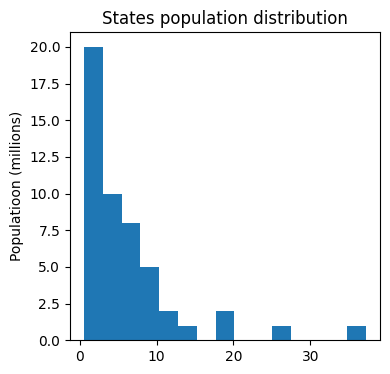

In [74]:
ax = (state_df["Population"] / 1_000_000).plot.hist(figsize=(4,4),bins=15)
ax.set_ylabel('Populatioon (millions)')
ax.set_title("States population distribution")

### Statistical moments
In statistics theory, location and variabilit are referred as the first and the second moment moments of distribution. The third moment is skewness, which describes wheter the data is skewed to larger or smaller values, or equally distributed (it is about symmetricy of distribution). The fourth moment is kurtosis which describes the shape of distribution - wheter data distribution is close to the normal normal distrubtion, whether it is flattened or prone to extreme values

### Density plot ('smoothened histogram')

Text(0.5, 0, 'Murder Rate (per 100,000)')

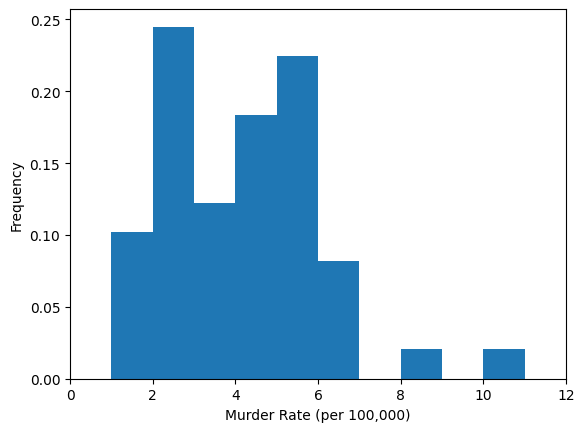

In [78]:
fig = state_df['Murder.Rate'].plot.hist(density=True, xlim=[0,12], bins=range(1,12))
fig.set_xlabel('Murder Rate (per 100,000)')

Key distinction between histogram and density plot is that, on the y-axis of density plot we see proportion of records belonging to that bin in comparison to the total record count, while with the histogram on the y-axis we see total count of records belonging to said bin.

## Exploring binary and categorical data 
- Mode - most commonly occuring category or value in data set
- Expected value - value which probability of occurence is the highest (mean of values). To calculate expected value of categorical data, we need to associate it with numerical values, so that we can calculte the average value.

In [102]:
dfw = pd.read_csv('dfw_airline.csv')
dfw  = dfw.transpose().sort_values(by=0,ascending=False)



Text(0, 0.5, 'Count')

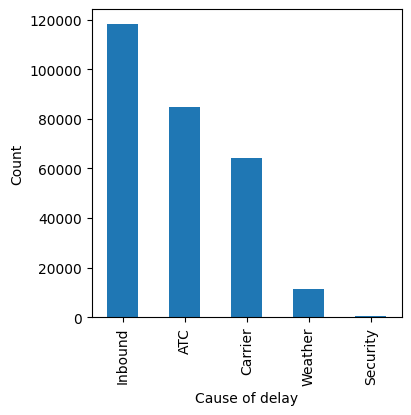

In [103]:

ax = dfw.plot.bar(figsize=(4,4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')


### Expected value
Expected value is a sort of weighted mean, where weights are probabilities associcieted with data. For example, if we know that 5% of our clients will purchase 300$ service, 15% will buy 50% and the remaining 80% won't buy anything, we can calculate the expected value of clients purchase, as weighted mean. <br>
EV= 0 . 05 300 + 0 . 15 50 + 0 . 80 0 = 22 . 5 <br>

### Correlation 
Correlation is measures of association between variables. Corelation can be positive, meaning that higher X is associated with higher Y. Correlation can also negative, when higher values of X are associated with lower values of Y. We say that variables are not correlated when there is no such association (there is no simmilarity in how the values of variables are changing) <br>

To show correlation we can use:
- correlation matrix
- scatter plot


### Pearson's correlation coefficient
The idea standing behind Pearson's correlation coefficient is that we compare how the variables are deviating from their average values in comparison to their standard deviations. In the numerator we sum product of deviaton of each variable. Numeratoer therefore can tak positive values if variables deviate in similar manner, negative if the manner is opposite or could be 0 if.  IN the denominator we have product of (n-1) and standard deviation of each variable. To sum up, we compare the deviation of variables and if that deviation is in simmilar matter or not.
![Pearson's correlation coefficient]() <br>
Unfortunatlly, Pearson's coeffiecient is senstive to outliers. However there are robust metrics to compute coefficient.
